<table style="width:100%">
  <tr>
    <td valign="top"><img src="../data/img/FER_logo_2.png" width=300 height=80 align="left"></td>
    <td valign="top"><img src="../data/img/LARES_2_transparent.png" width=250 height=80 align="right"></td>
  </tr>
 </table>

# Deep learning - classification of iris flowers

In this notebook, we will train and evaluate a new simple 'deep' learning model. The model will be based on a multilayer perceptron neural network (MLP NN) and implemented by using the Google [Tensorflow](https://www.tensorflow.org/) and [Keras](https://keras.io/) libraries.

In [1]:
# data processing
import numpy as np
import pandas as pd
import random

# sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# plotting libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# other
import warnings
import joblib
warnings.filterwarnings("ignore", category=FutureWarning)

## Auxiliary functions

We prepare some auxiliary functions to simplify different parts of the process. The plotting functions differ from those of the previous code because we now have a classification problem instead of a regression one.

In [2]:
# plotting
def plot_decision_regions(X_test, y_test, y_pred):
    data = X_test
    data['wrong_prediction'] = np.where(np.argmax(y_pred, axis=1) != y_test['Species'], True, False)
    data['Species'] = y_test['Species']
    sns.scatterplot(data=X_test, x=X_test.columns[0], y=X_test.columns[2], 
                    palette='deep', hue='Species', style='wrong_prediction')
    plt.show()
    sns.scatterplot(data=X_test, x=X_test.columns[1], y=X_test.columns[3], 
                    palette='deep', hue='Species', style='wrong_prediction')
    plt.show()
    
    
def plot_value_array(predictions_array, true_label, predictions_name, i, colors_style='dark'):
    plt.xticks(range(3))
    plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    thisplot = plt.bar(range(3), predictions_array, color="#777777", width=0.5)
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    plt.legend(['test case ' + str(i) + '\n' + predictions_name], fontsize=10)

    if colors_style == 'light':
        thisplot[predicted_label].set_color('#DE3163')
        thisplot[true_label].set_color('#6495ED')    
    else:
        thisplot[predicted_label].set_color('red')
        thisplot[true_label].set_color('blue')
        
        
def plot_individual_predictions(y_test, y_pred1, y_pred2=None):
    num_rows = 5
    num_cols = 2
    num_images = num_rows*num_cols
    plt.figure(figsize=(5*num_cols, 3*num_rows))
    plt.suptitle('The probability that a particular iris belongs to a particular species', fontsize=15)
    
    for i in range(num_images):
        plt.subplot(num_rows, 2*num_cols, 2*i+1)
        plot_value_array(y_pred1[i], int(y_test.iloc[i]), 'y_simple', i, colors_style='light')
    
        if y_pred2 is not None:
            plt.subplot(num_rows, 2*num_cols, 2*i+2)
            plot_value_array(y_pred2[i], int(y_test.iloc[i]), 'y_pred', i, colors_style='dark')
        
    plt.tight_layout()
    plt.show()

# Neural network model for regression

Let us begin with training the neural network model for the classification task (classification of iris flowers).
Again, as seen before, the process can be divided into the usual parts, as follows:

0. Preprocess data

1. Create/build model

2. Tune model

3. Evaluate model

4. Hands on

## 0. (Pre)process data
We will preprocess the data such that it is ready to be plugged into the model. To solve the classification task with neural networks, scaling is also an important part. However, since, as in any classification task, the outputs of the model have a limited number of different values. Therefore, the outputs do not need to be scaled, and instead we will use one-hot encoding.

In [3]:
# location of the data on disk - relative path
data_src = '../data/iris/'

In [4]:
# Load training data
X_train = pd.read_csv(data_src + 'X_train.csv',index_col='Id')
y_train = pd.read_csv(data_src + 'y_train.csv',index_col='Id')
# Load test data
X_test = pd.read_csv(data_src + 'X_test.csv',index_col='Id')
y_test = pd.read_csv(data_src + 'y_test.csv',index_col='Id')

In [5]:
# Scale data
ss_input = StandardScaler()

X_train_scaled = ss_input.fit_transform(X_train)
X_test_scaled = ss_input.transform(X_test)

## 1. Create/Build model
Here, as with regression, we will import the libraries needed to work with neural networks.

In [6]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import regularizers
from tensorflow.keras.losses import SparseCategoricalCrossentropy

Before we continue, we have to think about reproducibility of our experiments!

In [7]:
# fix other seeds
random.seed(321)
np.random.seed(321)

# fix tensorflow seeds
tf.random.set_seed(321)

### Basic way of creating a NN model

First, we do the classification with a simple neural network model. In general, after the model is initialized ([tf.keras.Sequential](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)), we continue by iteratively adding additional layers.
Since we are creating a MLP NN model, we add dense, fully connected layers ([tf.keras.layers.Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)) with just basic parameters:
   - number of neurons in the layer,
- activation function choice.

The model is mostly the same as the one from the regression task. The only significant difference is the 'softmax' activation function on the output so that the model predictions can be presented as percentages.

In [8]:
# initialize the NN model (use tf.keras.Sequential)
model = tf.keras.Sequential()

# add input layer to the model (layers.Input+layers.Dense) (3 neurons, input dim 4 and linear activation function)
model.add(layers.Input(shape=(4,)))
model.add(layers.Dense(3, activation='linear'))

# add hidden layers to the model (layers.Dense, 3 neurons)
model.add(layers.Dense(3, activation='relu'))
model.add(layers.Dense(3, activation='relu'))

# output layer (dense output layer with linear activation function)
model.add(layers.Dense(3, activation='softmax'))

By printing the model specifications, we can see the increased number of parameters in the last layer compared to the regression task. The reason is that we now have 3 neurons in the output layer.

In [9]:
# print out the model structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 3)                   │              15 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

## 2. Fit model
Once the model is built, we will configure the training procedure using the Keras Model.compile method. The most important arguments to compile are the loss and the optimizer. This time, as a loss function we will use 'categorical cross entropy' which is more suitable to the classification task than 'mae' or 'mse'.

categorical crossentropy formula: 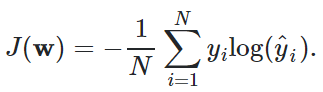

In [10]:
# compile the NN model (MAE, ADAM)
model.compile(loss=SparseCategoricalCrossentropy(from_logits=False), 
              optimizer='adam',
              metrics=['accuracy'])

# fit the NN model on the dataset (X/y train scaled, 8 batch size, 100 epochs)
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=8);

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2215 - loss: 1.1318
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3149 - loss: 1.1163 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3374 - loss: 1.1056 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3783 - loss: 1.1017 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3904 - loss: 1.0983 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4492 - loss: 1.0915 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4710 - loss: 1.0800 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6105 - loss: 1.0541 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6549 - loss: 1.0009 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6787 - loss: 0.9427 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6787 - loss: 0.8920 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

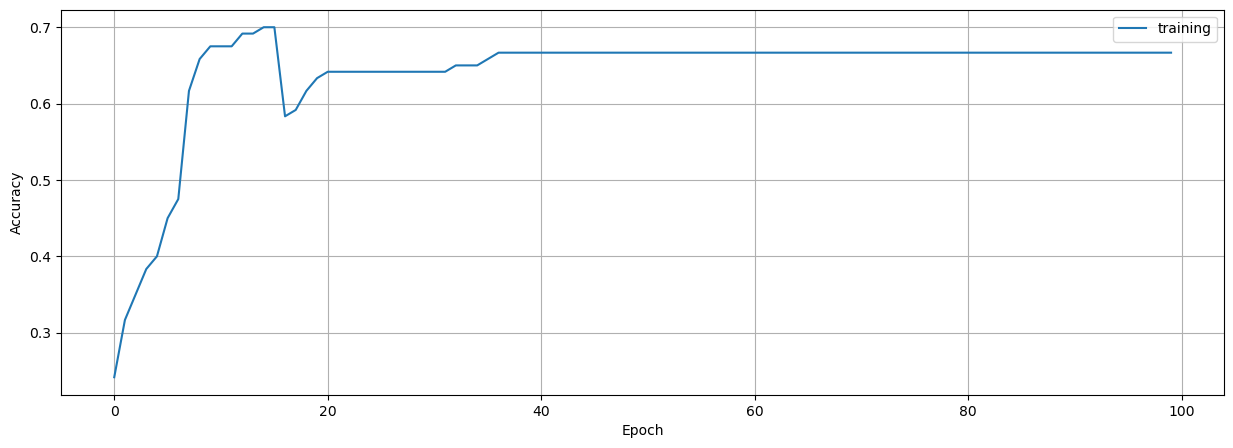

In [11]:
# plot the values of the loss function on the training dataset during the tuning epochs
plt.figure(figsize=(15, 5))
plt.plot(history.history['accuracy'], label='training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.grid()
plt.show()

## 3. Evaluate model
Now that we have obtained our NN model, we will generate predictions and evaluate the model accuracy.

In [12]:
# errors dataframe
error = pd.DataFrame(index=['scce', 'accuracy'], columns=['NN simple', 'NN playable'], data=np.NaN)

In [13]:
# generate predictions
y_pred = model.predict(X_test_scaled)
y_simple = y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [14]:
# evaluate model accuracy
nn_scce, nn_acc = model.evaluate(X_test_scaled,  y_test)

error['NN simple'] = [nn_scce, nn_acc]
error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6667 - loss: 0.5264


,NN simple,NN playable
scce,0.526363,NaN
accuracy,0.666667,NaN


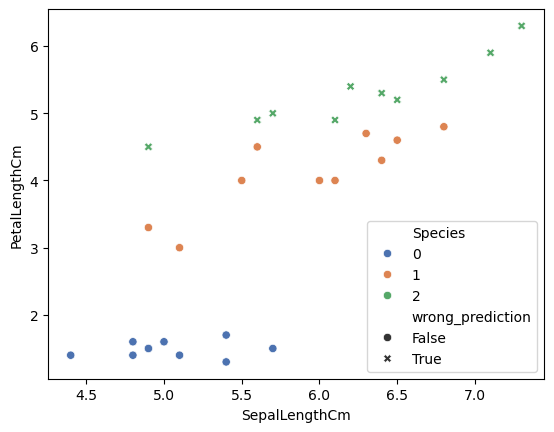

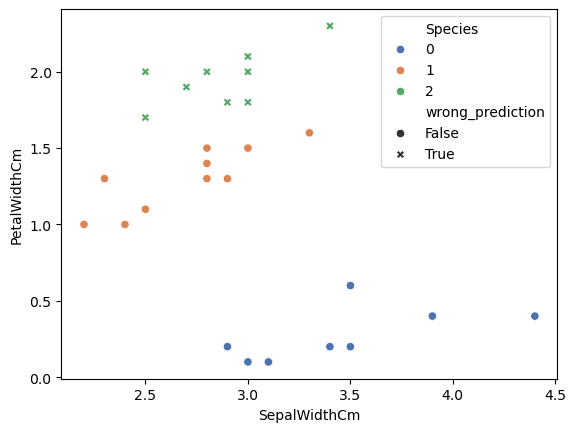

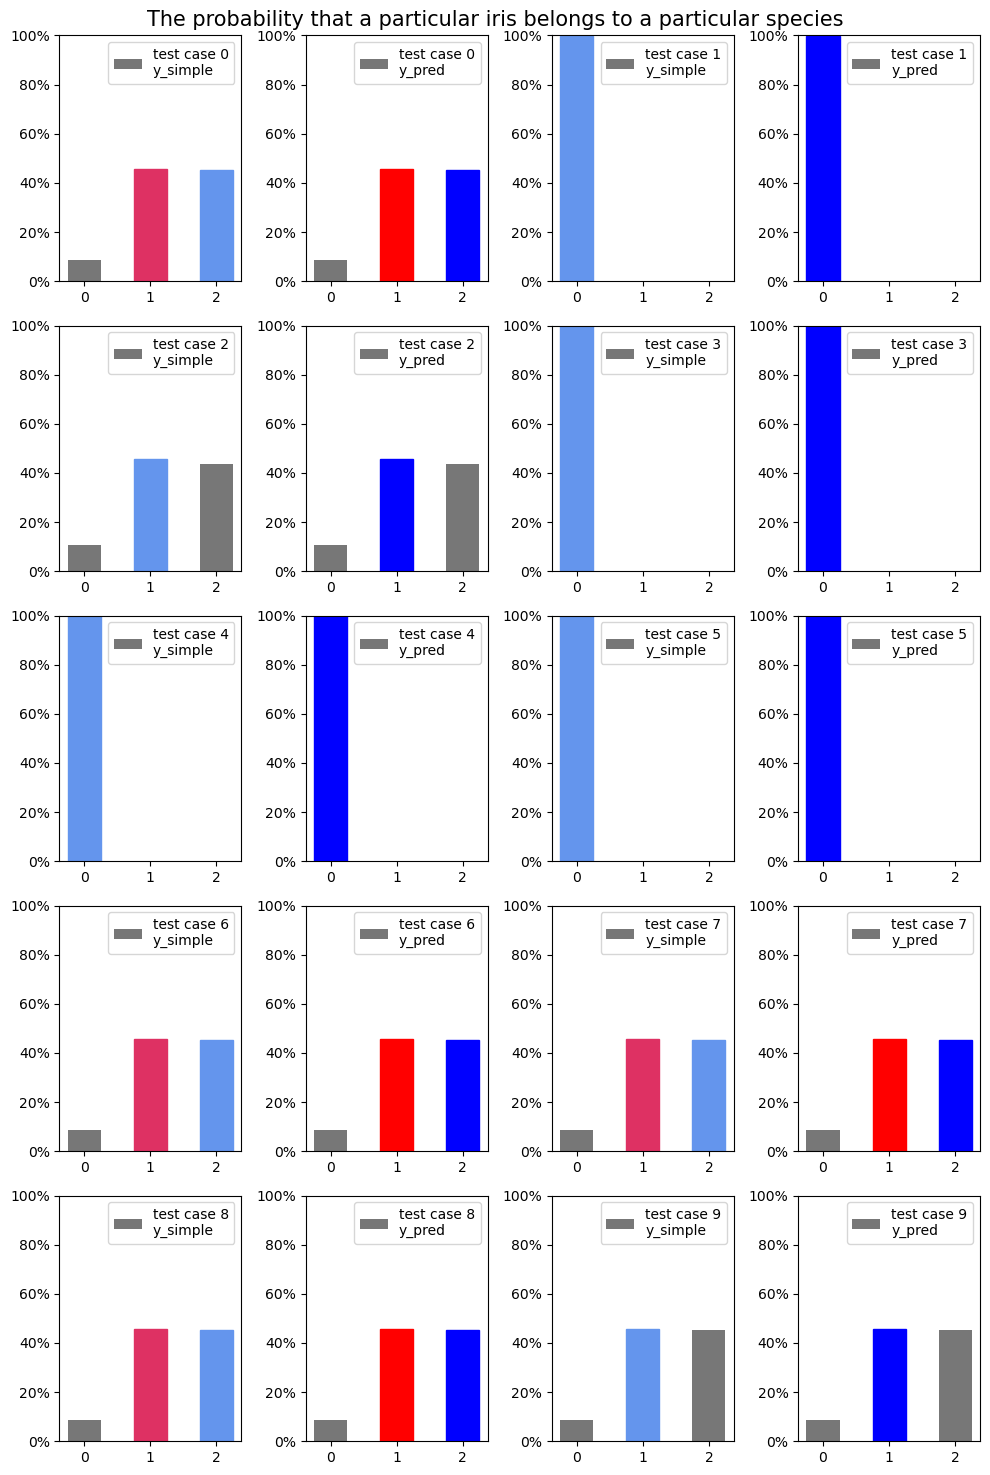

In [15]:
# visualize the obtained results by using the prepared aux function
plot_decision_regions(X_test, y_test, y_pred)
plot_individual_predictions(y_test, y_simple, y_pred)

### Ready-to-play NN model
To make things more manuverable, we will again divide our model build process into two separate functions:
- build_nn_model: part of the code that creates the NN object. As parameters we have used the number of neurons per layer, number of layers, number of model inputs, the number of model outputs, activation function and regularizer.
- tune_nn_model: part of the code that executes the model training procedure. As parameters we have used the scaled X train/test and y train/test datasets. The number of neurons, numver of layers, activation function and regularizer are passed into the build_nn_model function.

Additionally, we will now further separate the training dataset into the training and validation parts, such that the validation part can be utilized to implement the early stopping procedure of NN tuning.

In [16]:
# form train and validation datasets
X_train_scaled, X_valid_scaled, y_train, y_valid = train_test_split(X_train_scaled, y_train, 
                                                                    test_size=0.2, random_state=321, shuffle=False)

In [17]:
def build_nn_model(num_of_neurons, num_of_layers, num_of_inputs, num_of_outputs, activation, regularizer):

    # initialize the model
    model = tf.keras.Sequential()

    # first layer (input and dense input layer with a linear activation function)
    model.add(layers.Input(shape=(num_of_inputs,)))
    model.add(layers.Dense(num_of_neurons, activation='linear'))

    # hidden layers (arbitrary number of layers, neurons, activation function and regularization)
    for layer in range(1, num_of_layers + 1):
        if regularizer == None:
            model.add(layers.Dense(num_of_neurons, activation=activation))
        elif regularizer in ['l1', 'L1']:
            model.add(layers.Dense(num_of_neurons, activation=activation, kernel_regularizer=regularizers.l1()))
        elif regularizer in ['l2', 'L2']:
            model.add(layers.Dense(num_of_neurons, activation=activation, kernel_regularizer=regularizers.l2()))
        elif regularizer in ['l12', 'L12']:
            model.add(layers.Dense(num_of_neurons, activation=activation, kernel_regularizer=regularizers.l12()))
        elif regularizer in ['dropout', 'Dropout']:
            model.add(layers.Dense(num_of_neurons, activation=activation))
            model.add(layers.Dropout(0.1))
        else:
            raise Exception('Regularizer type doesn\'t exist')
            
    # output layer (dense output layer with softmax activation function)
    model.add(layers.Dense(num_of_outputs, activation='softmax'))

    return model

Additionally, we will again implement the early stopping procedure.

We have pre-set the tuning procedure max epochs number to 1000, and the early stopping algorithm patience to 100 epochs. We are monitoring the validation dataset mean absolute error. The batch size is set to 8 samples.

In [18]:
def tune_nn_model(X_train_scaled, X_valid_scaled, y_train, y_valid, 
                  num_of_neurons, num_of_layers, activation, regularizer, optimizer):

    # callbacks for early stopping of the model training procedure
    es = EarlyStopping(monitor='val_loss', mode='min', patience=100)
    mc = ModelCheckpoint('../models/NN_iris_tmp.keras', monitor='val_loss', mode='min', save_best_only=True)

    # create NN model (utilize the build_nn_model function)
    model = build_nn_model(num_of_neurons, num_of_layers, 
                           X_train_scaled.shape[1], int(y_train.nunique()), 
                           activation, regularizer)

    # compile the NN model
    model.compile(loss=SparseCategoricalCrossentropy(from_logits=False), 
                  optimizer=optimizer, 
                  metrics=['accuracy'])

    # fit the NN model on the dataset and store the model as well as the training procedure
    history = model.fit(X_train_scaled, y_train,
                        validation_data=(X_valid_scaled, y_valid),
                        epochs=1000,
                        batch_size=8,
                        callbacks=[es, mc])

    return model, history

Test different numbers of layers and different numbers of neurons in the layers of the neural network. More input parameters require a more complex network.

Try different activation functions, regularizers and optimizers and explore their parameters. Documentation for these hyperparameters can be found at the following links:

1) activation - https://www.tensorflow.org/api_docs/python/tf/keras/activations

2) regularizer - https://www.tensorflow.org/api_docs/python/tf/keras/regularizers

3) dropout (regularization type) - https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dropout

4) optimizer - https://www.tensorflow.org/api_docs/python/tf/keras/optimizers

In [19]:
# fit (train) the NN model
num_of_neurons = 5
num_of_layers = 2
activation = 'relu'  # 'relu', 'sigmoid', 'tanh' ...
regularizer = None  # None, 'l1', 'l2', 'l12' or 'dropout'
optimizer = 'adam'  # 'SGD','RMSprop', 'adam' ...
model, history = tune_nn_model(X_train_scaled, X_valid_scaled, y_train, y_valid, 
                               num_of_neurons, num_of_layers, activation, regularizer, optimizer)
model.summary()

Epoch 1/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.3130 - loss: 1.2419 - val_accuracy: 0.4167 - val_loss: 1.0245
Epoch 2/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3130 - loss: 1.1326 - val_accuracy: 0.4167 - val_loss: 0.9494
Epoch 3/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3130 - loss: 1.0448 - val_accuracy: 0.4167 - val_loss: 0.8851
Epoch 4/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3356 - loss: 0.9779 - val_accuracy: 0.4167 - val_loss: 0.8326
Epoch 5/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3537 - loss: 0.9268 - val_accuracy: 0.4167 - val_loss: 0.7901
Epoch 6/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3610 - loss: 0.8843 - val_accuracy: 0.4167 - val_loss: 0.7529
Epoch 7/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3931 - loss: 0.8481 - val_accuracy: 0.5833 - val_loss: 0.7219
Epoch 8/1000
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4317 - loss: 0.8183 - val_accu

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 5)                   │              25 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 5)                   │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 311 (1.22 KB)

 Trainable params: 103 (412.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 208 (836.00 B)

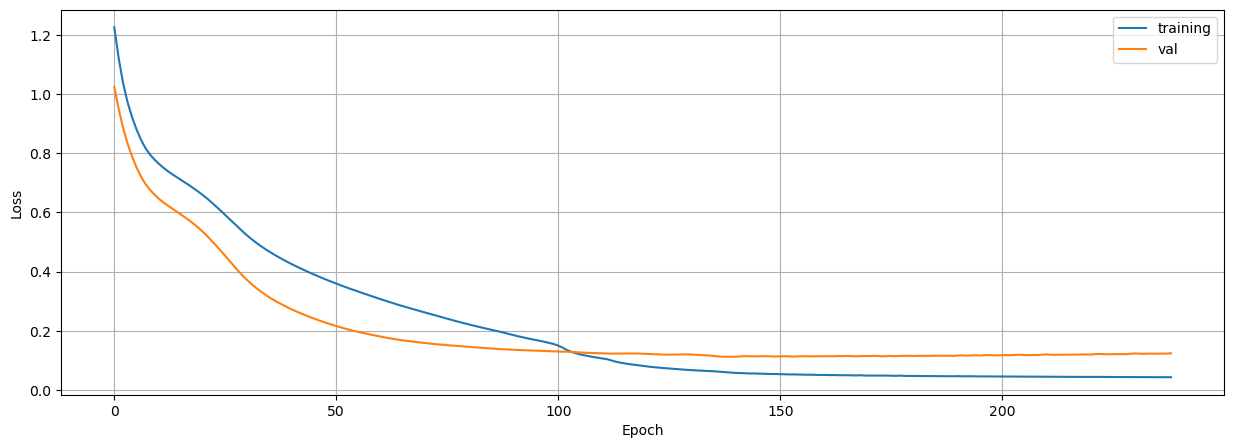

In [20]:
# plot the values of the loss function (on the training and the validation dataset) during the tuning epochs
plt.figure(figsize=(15, 5))
plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()
plt.show()

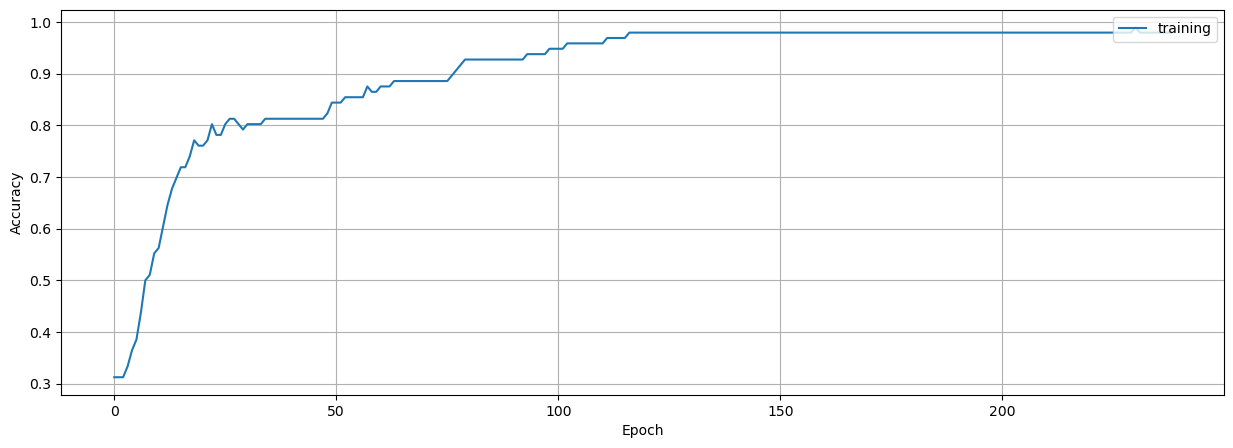

In [21]:
# plot the values of the loss function (on the training and the validation dataset) during the tuning epochs
plt.figure(figsize=(15, 5))
plt.plot(history.history['accuracy'], label='training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.grid()
plt.show()

In [22]:
# generate predictions
y_pred = model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


In [23]:
# evaluate model accuracy
nn_scce, nn_acc = model.evaluate(X_test_scaled,  y_test)

error['NN playable'] = [nn_scce, nn_acc]
error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9667 - loss: 0.1937


,NN simple,NN playable
scce,0.526363,0.193732
accuracy,0.666667,0.966667


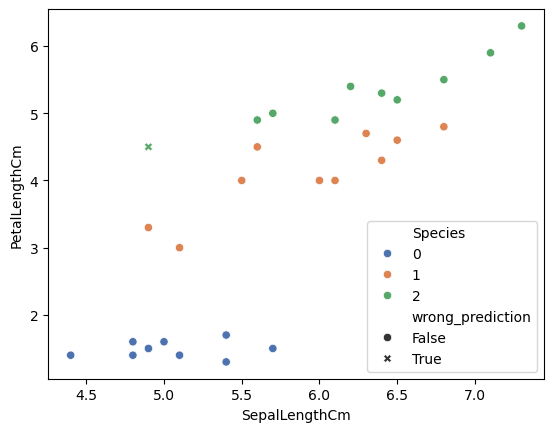

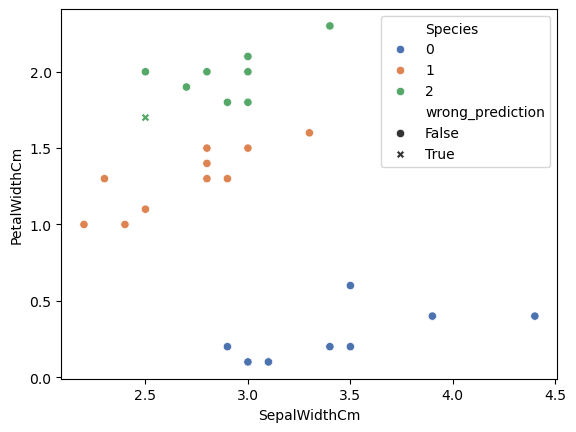

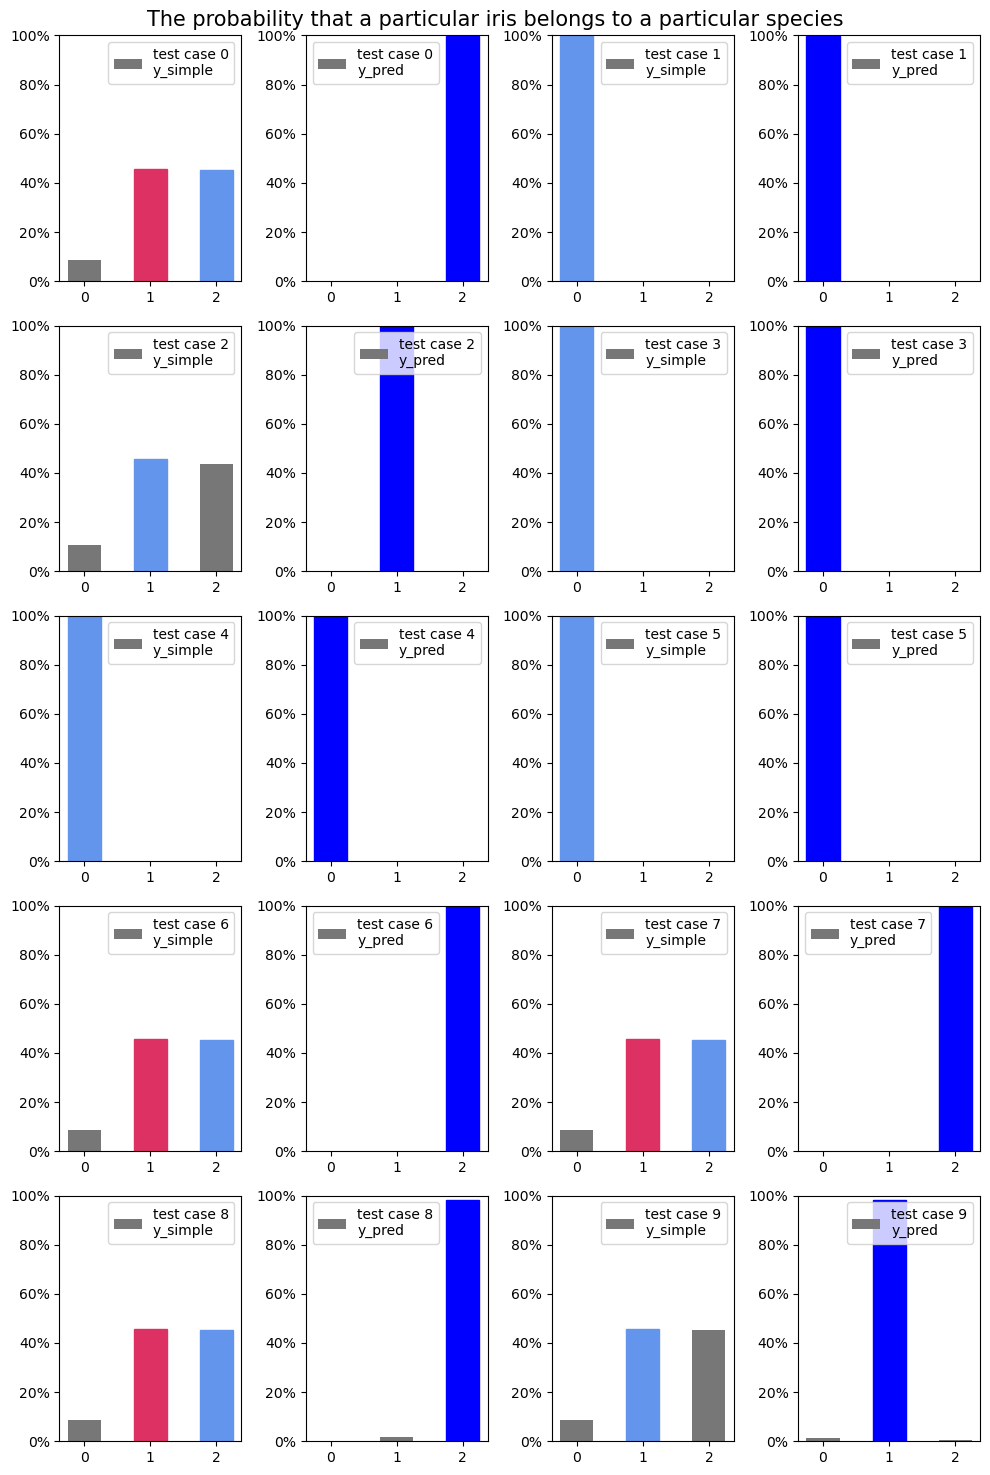

In [24]:
# plot results
plot_decision_regions(X_test, y_test, y_pred)
plot_individual_predictions(y_test, y_simple, y_pred)

## Hands-on

During the hands on part of the neural network modelling, you taks is to tune a NN with the following parameters:
- 4 input dimension and 3 output dimension (linear activation functions for input and softmax for output layer),
- 2 hidden layers (relu activation function, L2 regularization with 0.002 as regularization parameter),
- 10 neurons in each hidden layer,
- sparse categorical crossentropy loss function,
- ADAM optimizer with learning rate 0.003,
- 32 batch size,
- 200 epochs.

With the prepared code block, check the accuracy of the model.

In [25]:
regularizer = tf.keras.regularizers.L2(l2=0.002)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.003)

# initialize the NN model (use tf.keras.Sequential)
model = tf.keras.Sequential()

# add input layer to the model (layers.Input+layers.Dense) (3 neurons, input dim 4 and linear activation function)
model.add(layers.Input(shape=(4,)))

# add hidden layers to the model (layers.Dense, 3 neurons)
model.add(layers.Dense(10, activation='relu', kernel_regularizer=regularizer))
model.add(layers.Dense(10, activation='relu', kernel_regularizer=regularizer))

# output layer (dense output layer with linear activation function)
model.add(layers.Dense(3, activation='softmax'))

# compile the NN model (MAE, ADAM)
model.compile(loss=SparseCategoricalCrossentropy(from_logits=False), 
              optimizer=optimizer,
              metrics=['accuracy'])

# fit the NN model on the dataset (X/y train scaled, 8 batch size, 100 epochs)
history = model.fit(X_train_scaled, 
                    y_train, 
                    epochs=200, 
                    batch_size=32);

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3750 - loss: 1.0748
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4688 - loss: 1.0511 
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4779 - loss: 1.0305 
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5039 - loss: 1.0108 
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5208 - loss: 0.9912 
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5794 - loss: 0.9718 
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5651 - loss: 0.9537 
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5260 - loss: 0.9363 
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5169 - loss: 0.9189 
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5169 - loss: 0.9018 
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5169 - loss: 0.8852 
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5169 - loss

In [26]:
# generate predictions
y_pred = model.predict(X_test_scaled)

# evaluate model accuracy
nn_scce, nn_acc = model.evaluate(X_test_scaled,  y_test)

error['NN playable'] = [nn_scce, nn_acc]
error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9667 - loss: 0.1249


,NN simple,NN playable
scce,0.526363,0.124914
accuracy,0.666667,0.966667


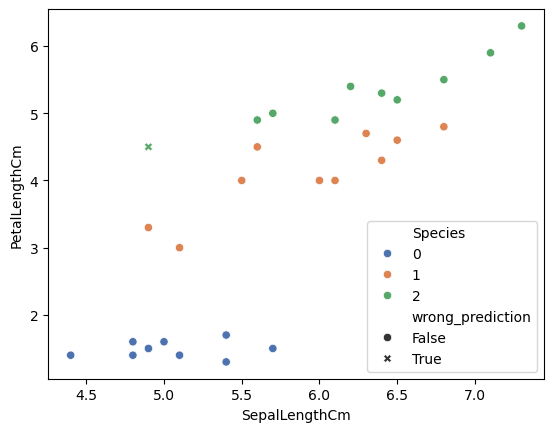

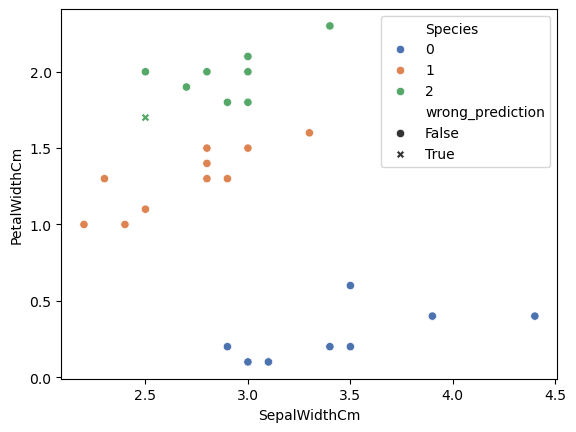

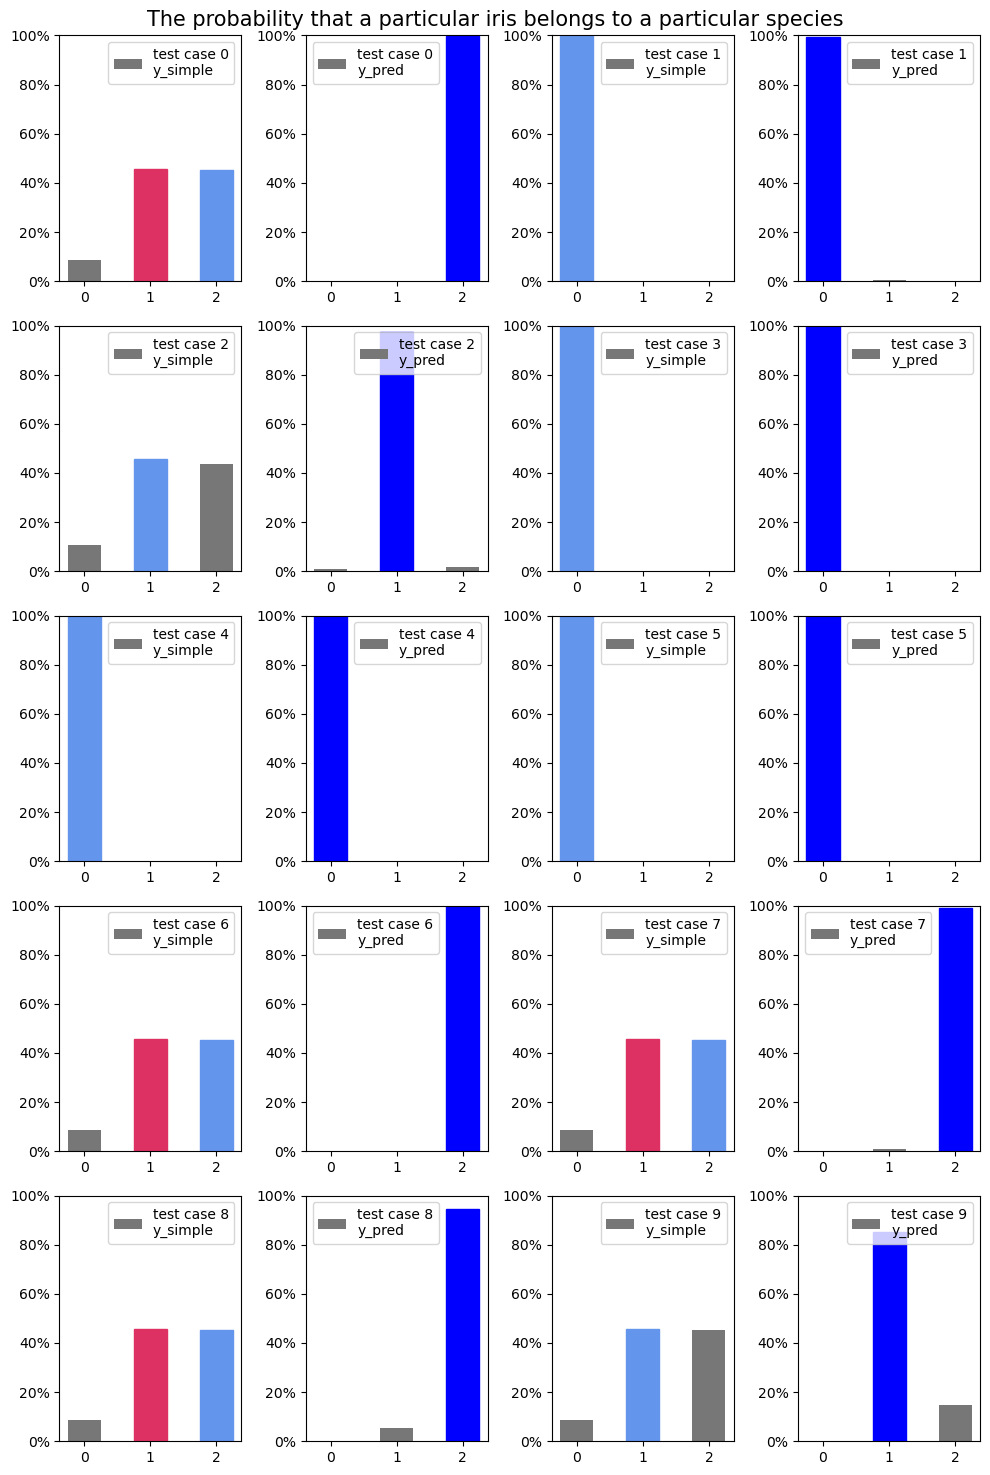

In [27]:
# plot results
plot_decision_regions(X_test, y_test, y_pred)
plot_individual_predictions(y_test, y_simple, y_pred)

## Save and load model
Finally, we will see how to save and load the resulting neural network model and the necessary parameters. 

At the beginning, we need to save the neural network model. This implies its architecture (network type, number of layers, layer sizes) and parameters whose values we obtained in training process (weight coefficients between neurons and bias). We save the architecture of the neural network in the file NN_iris_final.keras

In addition, to use the saved model we also need information on how to get from the output given by the neural network to the actual prediction value. That's why we need to save information about the scaler. ...

In [28]:
model.save('../models/NN_iris_final.keras')

joblib.dump(ss_input, '../models/NN_iris_input_scaler.pkl')

['../models/NN_iris_input_scaler.pkl']

Now let's load the saved models.

In [29]:
model_loaded = tf.keras.models.load_model('../models/NN_iris_final.keras')

ss_input_loaded = joblib.load('../models/NN_iris_input_scaler.pkl')

To test the loaded model we will load X_test and y_test again.

In [30]:
# Load test data
X_test_loaded = pd.read_csv(data_src + 'X_test.csv',index_col='Id')
y_test_loaded = pd.read_csv(data_src + 'y_test.csv',index_col='Id')

# Scale test data
X_test_scaled_loaded = ss_input.transform(X_test_loaded)

In [31]:
# generate predictions
y_pred_loaded = model_loaded.predict(X_test_scaled_loaded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


In [32]:
# evaluate model accuracy
nn_scce, nn_acc = model.evaluate(X_test_scaled,  y_test)

error['NN playable'] = [nn_scce, nn_acc]
error

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9667 - loss: 0.1249


,NN simple,NN playable
scce,0.526363,0.124914
accuracy,0.666667,0.966667




_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 4b_NN_Iris_  
_Instructors: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_  
_Intended user: XY_  
_Date: 1st January 1991_  

_References:_
- _Iris dataset: https://archive.ics.uci.edu/dataset/53/iris_
- _FISHER, R.A. (1936), THE USE OF MULTIPLE MEASUREMENTS IN TAXONOMIC PROBLEMS. Annals of Eugenics, 7: 179-188. https://doi.org/10.1111/j.1469-1809.1936.tb02137.x_
- _Tensorflow Machine Learning platform: https://www.tensorflow.org/_
- _Keras Deep Learning API: https://keras.io/_
- _Tensorflow Sequential NN model: https://www.tensorflow.org/api_docs/python/tf/keras/Sequential_

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_

